<table style="border: none; border-collapse: collapse;">
    <tr>
        <td style="width: 20%; vertical-align: middle; padding-right: 10px;">
            <img src="https://i.imgur.com/cGOOUZw.png" width="120">
        </td>
        <td style="width: 2px; text-align: center;">
            <font color="#1957d1" size="7">|</font><br>
            <font color="#1957d1" size="7">|</font>
        </td>
        <td>
            <p style="font-variant: small-caps;"><font color="#1957d1" size="5">
                <b>Revisión Sistemática PRISMA</b>
            </font></p>
            <p style="font-variant: small-caps;"><font color="#1957d1" size="4">
                Quality Assessment Fase 3
            </font></p>
            <p style="font-style: oblique;"><font color="#1957d1" size="3">
                Francisco Flores &bull; Marzo 2026
            </font></p>
        </td>
    </tr>
</table>

Este notebook ejecuta el **Quality Assessment PRISMA Fase 3** sobre los 85 papers que superaron el screening de Fase 2. Utiliza la API de OpenAI con GPT-4o-mini para evaluar la calidad metodológica de cada paper mediante 4 criterios QA en escala 0/0.5/1, y clasifica cada paper según su área de dominio.

**Criterios QA (escala 0 / 0.5 / 1):**
- **QA1** — Rigor del split experimental (train/test)
- **QA2** — Comparación con baselines
- **QA3** — Reporte de hyperparámetros
- **QA4** — Caracterización del dataset

**Área de dominio (clasificación única):**
- Salud y Biomedicina
- Ciencias Exactas y Computación
- Lenguaje y Humanidades
- Industria y Negocios
- Otros

**Score total:** 0–4 puntos. Umbrales: Alta calidad ≥ 3.0 | Calidad media 1.5–2.9 | Baja calidad < 1.5

## <font color='1957d1'>Configuración Inicial</font>

Importación de librerías y configuración del cliente OpenAI.

In [1]:
# - Importar librerías y configurar clientes -

import pandas as pd
import numpy as np
import anthropic
import fitz  # PyMuPDF
import json
import time
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from pydantic import BaseModel
from typing import Literal
import warnings
import os
from dotenv import load_dotenv

warnings.filterwarnings('ignore')

load_dotenv()

client = anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))
print(f"Cliente Anthropic (Haiku) configurado correctamente")

Cliente Anthropic (Haiku) configurado correctamente


## <font color='1957d1'>Modelo de Respuesta Estructurada</font>

Esquema Pydantic para los 4 criterios QA y la clasificación de área de dominio.

In [2]:
# - Definir esquema de respuesta estructurada para Quality Assessment -

class QualityAssessment(BaseModel):
    """
    Esquema de respuesta para Quality Assessment Fase 3.
    Cada criterio QA se evalúa en escala 0 / 0.5 / 1.
    El área de dominio es una clasificación única entre 5 categorías.
    """
    qa1_split:          Literal[0, 0.5, 1]
    qa2_baseline:       Literal[0, 0.5, 1]
    qa3_hyperparams:    Literal[0, 0.5, 1]
    qa4_dataset:        Literal[0, 0.5, 1]
    area_dominio:       Literal[
        "Salud y Biomedicina",
        "Ciencias Exactas y Computación",
        "Lenguaje y Humanidades",
        "Industria y Negocios",
        "Otros"
    ]
    justificacion:      str  # Breve justificación de los scores asignados

## <font color='1957d1'>Función de Lectura de PDFs</font>

In [3]:
# - Extracción de texto completo desde PDF -

def extract_text_from_pdf(pdf_path, max_pages=None):
    """
    Extrae texto completo de un PDF usando PyMuPDF.

    Args:
        pdf_path: Ruta al archivo PDF
        max_pages: Límite de páginas (None = todas)

    Returns:
        str: Texto extraído, o None si el PDF no tiene texto extraíble
    """
    doc = fitz.open(pdf_path)
    int_total_pages = len(doc)
    int_pages_to_process = min(int_total_pages, max_pages) if max_pages else int_total_pages

    lst_pages_text = [doc[i].get_text() for i in range(int_pages_to_process)]
    doc.close()

    str_full_text = "\n".join(lst_pages_text)

    if len(str_full_text.strip()) < 100:
        return None

    return str_full_text

## <font color='1957d1'>Prompt del Sistema</font>

System prompt con criterios QA explícitos y no ambiguos. Cada criterio define con precisión qué constituye cada score (0, 0.5, 1) para minimizar subjetividad en la evaluación.

In [4]:
# - Definir system prompt y tool schema para Quality Assessment -

SYSTEM_PROMPT_QA = """You are a rigorous methodological evaluator for a PRISMA systematic literature review on fine-tuning techniques for Large Language Models.

Your task is to assess the methodological quality of a research paper using 4 criteria, each scored on a 0 / 0.5 / 1 scale. You must also classify the paper's application domain.

Be STRICT and CONSISTENT. Base every score exclusively on explicit evidence found in the text. Do not infer or assume information that is not clearly stated.

---

QA1 — Experimental split rigor (train/test separation):
  SCORE 0: No split is reported. The paper does not mention how data was divided, or uses the same data for training and evaluation without separation.
  SCORE 0.5: A split is mentioned but without specific proportions or sizes (e.g., "we split the data into train and test" with no numbers, or only the total dataset size is given).
  SCORE 1: The split is explicitly reported with clear proportions or exact sizes for each subset (e.g., "80% train / 20% test", "1,000 train / 200 test", or train/validation/test sizes are all stated).

QA2 — Baseline comparison:
  SCORE 0: No comparison is made. The paper reports results for a single model configuration with no reference point.
  SCORE 0.5: The paper compares against exactly one baseline — either the base model without fine-tuning, a single prior method, or a single competing technique.
  SCORE 1: The paper compares against two or more baselines, or compares the proposed technique against multiple alternative fine-tuning methods or state-of-the-art models.

QA3 — Hyperparameter reporting:
  SCORE 0: No training hyperparameters are reported. The paper describes fine-tuning without specifying any configuration details.
  SCORE 0.5: Only 1 or 2 basic hyperparameters are reported (e.g., only learning rate, or only batch size) without a complete training configuration.
  SCORE 1: A complete or near-complete set of hyperparameters is reported, including at minimum: learning rate, batch size, and number of epochs or training steps. For PEFT methods, technique-specific parameters must also be present (e.g., LoRA rank and alpha, adapter bottleneck size, prefix length). Reporting optimizer type alone does not qualify for score 1.

QA4 — Dataset characterization:
  SCORE 0: The dataset is named or referenced but no further detail is provided — no domain, no task context, no size information.
  SCORE 0.5: The dataset name AND either its domain/task context OR its size are reported, but not both.
  SCORE 1: The dataset is fully characterized with all three: (a) name or clear identifier, (b) domain and task context (e.g., "SQuAD for reading comprehension", "MIMIC-III for clinical NLP"), AND (c) size or number of samples (total, or broken down by split).

---

DOMAIN CLASSIFICATION — assign exactly one category:
  "Salud y Biomedicina": clinical NLP, medical records, biomedical text, drug discovery, mental health, radiology, genomics, patient data.
  "Ciencias Exactas y Computación": code generation, mathematical reasoning, software engineering, formal verification, programming tasks, cybersecurity, computer science benchmarks.
  "Lenguaje y Humanidades": general NLP tasks (translation, summarization, sentiment analysis, NER, QA on general corpora), linguistics, literature, social media text, news.
  "Industria y Negocios": finance, legal, education, customer service, e-commerce, HR, logistics, enterprise applications.
  "Otros": any domain that does not clearly fit the above categories.

---

COMMON SCORING TRAPS — these cases must NOT receive score 1:

QA1:
  - "We used the standard split of [benchmark]" → 0.5 (no explicit sizes reported)
  - "The dataset was divided into train and test sets" → 0.5 (split mentioned, no sizes)
  - "We used 10,000 samples for evaluation" → 0.5 (only test size given, train size missing)
  - Using a well-known benchmark does NOT imply its split sizes are reported — they must appear explicitly in the paper.

QA3:
  - "We applied LoRA with lr=2e-5 for 3 epochs" → 0.5 (missing rank and alpha)
  - "Training used batch size 16 and AdamW optimizer" → 0.5 (missing lr and epochs)
  - "We followed the default LoRA configuration" → 0 (no specific values reported)
  - "We used LoRA with rank=8" → 0.5 (missing lr, batch size, epochs)
  - For ANY PEFT method: rank/alpha (LoRA), bottleneck size (Adapters), or prefix length (Prefix Tuning) are REQUIRED for score 1. Their absence forces score 0.5 even if all basic hyperparameters are present.
  - Mathematical formulation of a technique (e.g., rank appearing in equations) does NOT count as hyperparameter reporting. Values must appear explicitly in an experimental setup section or configuration table.
  - "Paper describes model architecture mathematically but provides no training configuration table" → 0 or 0.5 depending on how many values are explicitly stated.

QA4:
  - "We used SQuAD" → 0 (name only)
  - "We evaluated on MIMIC-III with 50,000 records" → 0.5 (name + size, but no task/domain description)
  - "We used a clinical NLP dataset of 5,000 notes" → 0.5 (domain + size, but no dataset name)
  - "We used SQuAD for question answering" → 0.5 (name + domain, but no size)

---

FINAL CHECK — before assigning any score of 1.0, ask yourself:
  "Is this information EXPLICITLY written in the paper, or am I inferring it from context or prior knowledge?"
  If you are inferring → the score cannot be 1.0.

---

After evaluation, call the registrar_qa tool with your assessment."""


QA_TOOL = {
    "name": "registrar_qa",
    "description": "Registra el Quality Assessment metodológico del paper según los 4 criterios QA y clasifica su área de dominio.",
    "input_schema": {
        "type": "object",
        "properties": {
            "qa1_split": {
                "type": "number",
                "enum": [0, 0.5, 1],
                "description": "Score QA1: rigor del split experimental. 0=no reportado, 0.5=mencionado sin tamaños, 1=explícito con proporciones o tamaños exactos."
            },
            "qa2_baseline": {
                "type": "number",
                "enum": [0, 0.5, 1],
                "description": "Score QA2: comparación con baselines. 0=ninguno, 0.5=exactamente uno, 1=dos o más baselines."
            },
            "qa3_hyperparams": {
                "type": "number",
                "enum": [0, 0.5, 1],
                "description": "Score QA3: reporte de hyperparámetros. 0=ninguno, 0.5=1-2 básicos sin configuración completa, 1=completo incluyendo técnica-específicos para PEFT. Mathematical formulations do NOT count."
            },
            "qa4_dataset": {
                "type": "number",
                "enum": [0, 0.5, 1],
                "description": "Score QA4: caracterización del dataset. 0=solo nombre, 0.5=nombre+dominio O nombre+tamaño, 1=nombre+dominio+tamaño los tres presentes."
            },
            "area_dominio": {
                "type": "string",
                "enum": [
                    "Salud y Biomedicina",
                    "Ciencias Exactas y Computación",
                    "Lenguaje y Humanidades",
                    "Industria y Negocios",
                    "Otros"
                ],
                "description": "Área de dominio principal del paper."
            },
            "justificacion": {
                "type": "string",
                "description": "Justificación breve (2-4 oraciones en inglés) con evidencia específica para cada score asignado."
            }
        },
        "required": ["qa1_split", "qa2_baseline", "qa3_hyperparams", "qa4_dataset", "area_dominio", "justificacion"]
    }
}

## <font color='1957d1'>Función de Evaluación</font>

Envía el texto completo del PDF a Claude Haiku via tool use estructurado y retorna un dict con los resultados del Quality Assessment.

In [5]:
# - Función de evaluación QA via Anthropic API con tool use -

MODEL_QA = "claude-haiku-4-5-20251001"

def evaluate_quality(pdf_text, title, model=MODEL_QA):
    """
    Evalúa la calidad metodológica de un paper usando Claude Haiku via tool use.

    Args:
        pdf_text: Texto completo extraído del PDF
        title: Título del paper
        model: Modelo de Anthropic a utilizar

    Returns:
        dict con qa1_split, qa2_baseline, qa3_hyperparams, qa4_dataset,
        area_dominio, justificacion — o None si no se obtuvo respuesta del tool
    """
    str_user_prompt = f"""Paper Title: {title}

Full Text:
{pdf_text}

Evaluate the methodological quality of this paper using the 4 QA criteria and classify its application domain. Call the registrar_qa tool with your assessment."""

    response = client.messages.create(
        model=model,
        max_tokens=1024,
        system=SYSTEM_PROMPT_QA,
        tools=[QA_TOOL],
        tool_choice={"type": "any"},
        messages=[{"role": "user", "content": str_user_prompt}]
    )

    tool_block = next(
        (block for block in response.content if block.type == "tool_use"),
        None
    )

    if tool_block is None:
        return None

    return tool_block.input

## <font color='1957d1'>Carga de PDFs</font>

Carga los PDFs del corpus final de Fase 2 (85 papers INCLUIR).

In [6]:
# - Cargar PDFs del corpus final Fase 2 -

PDF_DIR = Path("Data/Pdfs-Fase2")

if not PDF_DIR.exists():
    raise ValueError(f"Directorio {PDF_DIR} no existe.")

lst_available_pdfs = list(PDF_DIR.glob("*.pdf"))

print(f"PDFs encontrados: {len(lst_available_pdfs)}")

df = pd.DataFrame({
    'pdf_filename': [pdf.name for pdf in lst_available_pdfs],
    'pdf_path':     [str(pdf) for pdf in lst_available_pdfs]
})

PDFs encontrados: 85


### <font color='1957d1'>Configuración de Ejecución</font>

Modo TEST con `SAMPLE_SIZE = 5` para validar antes de producción. Cambiar a `None` para procesar todos los PDFs.

El sistema de checkpoint guarda el progreso después de cada paper. Si la ejecución se interrumpe, retoma automáticamente desde el último paper procesado.

**`time.sleep` recomendado:**
- `time.sleep(1)` — tier alto, contextos cortos
- `time.sleep(3)` — uso general con GPT-4o-mini
- `time.sleep(10)` — si se presentan errores de rate limit

In [7]:
# - Configurar modo de ejecución con checkpoint -

SAMPLE_SIZE     = None  # TEST: N entero | Producción: None
CHECKPOINT_FILE = Path("Exports/Phase3/phase3_checkpoint.csv")

if SAMPLE_SIZE:
    df_qa = df.head(SAMPLE_SIZE).copy()
    print(f"Modo TEST: {SAMPLE_SIZE} PDFs")
else:
    df_qa = df.copy()
    print(f"Modo PRODUCCIÓN: {len(df_qa)} PDFs")

# Retomar desde checkpoint si existe
if CHECKPOINT_FILE.exists():
    df_checkpoint = pd.read_csv(CHECKPOINT_FILE)
    df_qa = df_qa.merge(
        df_checkpoint[['pdf_filename', 'qa1_split', 'qa2_baseline',
                       'qa3_hyperparams', 'qa4_dataset', 'qa_score_total',
                       'qa_nivel', 'area_dominio', 'justificacion', 'extraction_error']],
        on='pdf_filename', how='left'
    )
    int_ya_procesados = df_qa['qa1_split'].notna().sum()
    print(f"Checkpoint encontrado — retomando desde paper {int_ya_procesados + 1}")
else:
    df_qa['qa1_split']       = None
    df_qa['qa2_baseline']    = None
    df_qa['qa3_hyperparams'] = None
    df_qa['qa4_dataset']     = None
    df_qa['qa_score_total']  = None
    df_qa['qa_nivel']        = ''
    df_qa['area_dominio']    = ''
    df_qa['justificacion']   = ''
    df_qa['extraction_error'] = False
    print("Sin checkpoint — iniciando desde cero")

Modo PRODUCCIÓN: 85 PDFs
Sin checkpoint — iniciando desde cero


## <font color='1957d1'>Ejecución del Quality Assessment</font>

Procesamiento secuencial de cada PDF: extracción de texto, evaluación QA mediante GPT-4o-mini, cálculo de score total y clasificación de nivel de calidad.

In [8]:
# - Loop principal Quality Assessment con checkpoint automático -

CHECKPOINT_FILE.parent.mkdir(parents=True, exist_ok=True)
int_total = len(df_qa)

for idx, row in df_qa.iterrows():

    # Saltar papers ya procesados
    if pd.notna(row['qa1_split']):
        continue

    str_filename = row['pdf_filename']
    str_pdf_path = row['pdf_path']
    str_title    = str_filename.replace('.pdf', '')

    print(f"Procesando [{df_qa.index.get_loc(idx)+1}/{int_total}]: {str_filename}")

    str_pdf_text = extract_text_from_pdf(str_pdf_path)

    if str_pdf_text is None:
        print(f"  → ERROR: PDF sin texto extraíble")
        df_qa.at[idx, 'extraction_error'] = True
        df_qa.at[idx, 'qa_nivel']         = 'ERROR'
    else:
        qa = evaluate_quality(str_pdf_text, str_title)

        flt_score_total = qa['qa1_split'] + qa['qa2_baseline'] + qa['qa3_hyperparams'] + qa['qa4_dataset']

        if flt_score_total >= 3.0:
            str_nivel = 'Alta calidad'
        elif flt_score_total >= 1.5:
            str_nivel = 'Calidad media'
        else:
            str_nivel = 'Baja calidad'

        df_qa.at[idx, 'qa1_split']       = qa['qa1_split']
        df_qa.at[idx, 'qa2_baseline']    = qa['qa2_baseline']
        df_qa.at[idx, 'qa3_hyperparams'] = qa['qa3_hyperparams']
        df_qa.at[idx, 'qa4_dataset']     = qa['qa4_dataset']
        df_qa.at[idx, 'qa_score_total']  = flt_score_total
        df_qa.at[idx, 'qa_nivel']        = str_nivel
        df_qa.at[idx, 'area_dominio']    = qa['area_dominio']
        df_qa.at[idx, 'justificacion']   = qa['justificacion']

        print(f"  Score: {flt_score_total}/4.0 ({str_nivel}) | Dominio: {qa['area_dominio']}")

    # Guardar checkpoint después de cada paper
    df_qa[[
        'pdf_filename', 'qa1_split', 'qa2_baseline', 'qa3_hyperparams',
        'qa4_dataset', 'qa_score_total', 'qa_nivel', 'area_dominio',
        'justificacion', 'extraction_error'
    ]].to_csv(CHECKPOINT_FILE, index=False)

    time.sleep(3)

print(f"\nQuality Assessment completado: {int_total} papers procesados")

Procesando [1/85]: adhikary2025medical.pdf
  Score: 4/4.0 (Alta calidad) | Dominio: Salud y Biomedicina
Procesando [2/85]: anghel2025courseeval.pdf
  Score: 3.5/4.0 (Alta calidad) | Dominio: Lenguaje y Humanidades
Procesando [3/85]: ao2025lora.pdf
  Score: 4/4.0 (Alta calidad) | Dominio: Ciencias Exactas y Computación
Procesando [4/85]: bao2025ecbti.pdf
  Score: 2.5/4.0 (Calidad media) | Dominio: Salud y Biomedicina
Procesando [5/85]: bayram2025medical.pdf
  Score: 4/4.0 (Alta calidad) | Dominio: Salud y Biomedicina
Procesando [6/85]: bui2025ft.pdf
  Score: 3.5/4.0 (Alta calidad) | Dominio: Salud y Biomedicina
Procesando [7/85]: cao2025lora.pdf
  Score: 3.5/4.0 (Alta calidad) | Dominio: Industria y Negocios
Procesando [8/85]: chao2025evaluating.pdf
  Score: 4/4.0 (Alta calidad) | Dominio: Salud y Biomedicina
Procesando [9/85]: chen2025adaptforever.pdf
  Score: 3.0/4.0 (Alta calidad) | Dominio: Lenguaje y Humanidades
Procesando [10/85]: chen2025ft.pdf
  Score: 4/4.0 (Alta calidad) | Dom

## <font color='1957d1'>Resumen de Resultados</font>

In [9]:
# - Resumen estadístico del Quality Assessment -

df_valid = df_qa[df_qa['qa_nivel'] != 'ERROR'].copy()
df_valid['qa_score_total'] = df_valid['qa_score_total'].astype(float)

print(f"Papers evaluados: {len(df_valid)}")
print(f"Score promedio:   {df_valid['qa_score_total'].mean():.2f} / 4.0")
print(f"Score mediana:    {df_valid['qa_score_total'].median():.2f}")
print(f"\nDistribución de niveles:")
print(df_valid['qa_nivel'].value_counts())
print(f"\nDistribución por área de dominio:")
print(df_valid['area_dominio'].value_counts())
print(f"\nPromedio por criterio QA:")
for str_col, str_label in [('qa1_split', 'QA1 Split'), ('qa2_baseline', 'QA2 Baseline'),
                            ('qa3_hyperparams', 'QA3 Hyperparams'), ('qa4_dataset', 'QA4 Dataset')]:
    print(f"  {str_label}: {df_valid[str_col].astype(float).mean():.2f}")

Papers evaluados: 85
Score promedio:   3.49 / 4.0
Score mediana:    3.50

Distribución de niveles:
qa_nivel
Alta calidad     74
Calidad media    11
Name: count, dtype: int64

Distribución por área de dominio:
area_dominio
Salud y Biomedicina               31
Lenguaje y Humanidades            22
Ciencias Exactas y Computación    20
Industria y Negocios              12
Name: count, dtype: int64

Promedio por criterio QA:
  QA1 Split: 0.84
  QA2 Baseline: 0.88
  QA3 Hyperparams: 0.82
  QA4 Dataset: 0.95


## <font color='1957d1'>Visualización de Resultados</font>

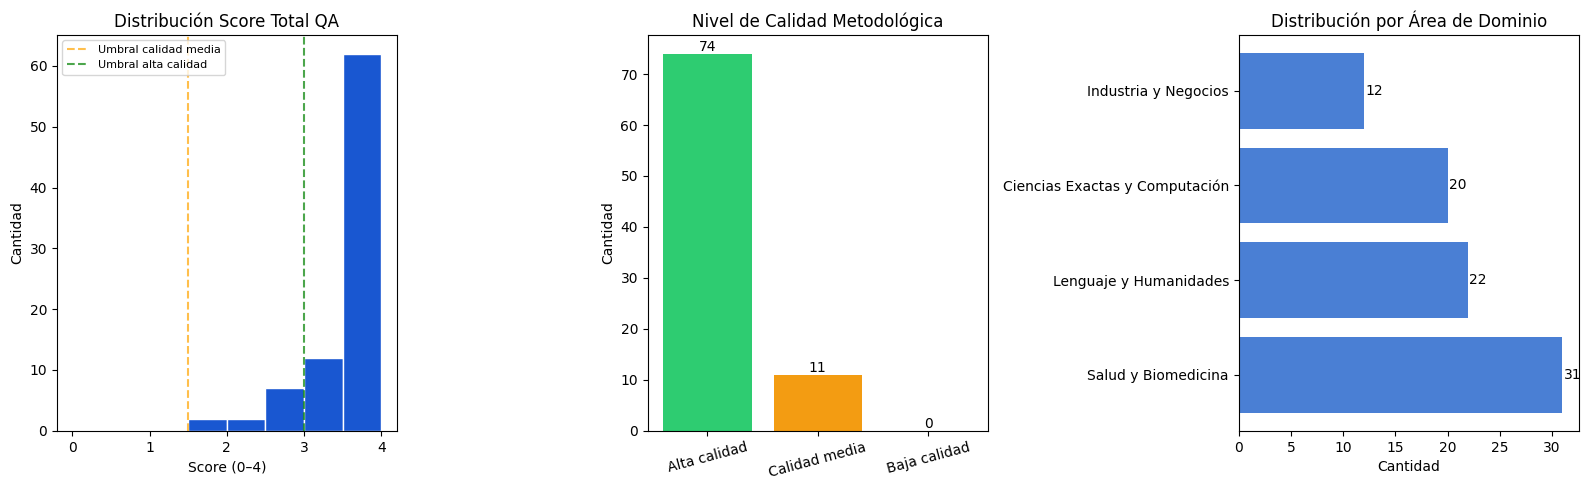

In [10]:
# - Distribución de scores y niveles de calidad -

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histograma de score total
axes[0].hist(df_valid['qa_score_total'].astype(float), bins=[0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4],
             color='#1957d1', edgecolor='white')
axes[0].axvline(x=1.5, color='orange', linestyle='--', alpha=0.7, label='Umbral calidad media')
axes[0].axvline(x=3.0, color='green',  linestyle='--', alpha=0.7, label='Umbral alta calidad')
axes[0].set_title('Distribución Score Total QA')
axes[0].set_xlabel('Score (0–4)')
axes[0].set_ylabel('Cantidad')
axes[0].legend(fontsize=8)

# Niveles de calidad
nivel_counts = df_valid['qa_nivel'].value_counts().reindex(
    ['Alta calidad', 'Calidad media', 'Baja calidad'], fill_value=0
)
bars = axes[1].bar(nivel_counts.index, nivel_counts.values,
                   color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[1].set_title('Nivel de Calidad Metodológica')
axes[1].set_ylabel('Cantidad')
axes[1].tick_params(axis='x', rotation=15)
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')

# Áreas de dominio
area_counts = df_valid['area_dominio'].value_counts()
axes[2].barh(area_counts.index, area_counts.values, color='#4a7fd4')
axes[2].set_title('Distribución por Área de Dominio')
axes[2].set_xlabel('Cantidad')
for i, v in enumerate(area_counts.values):
    axes[2].text(v + 0.1, i, str(v), va='center')

plt.tight_layout()
plt.show();

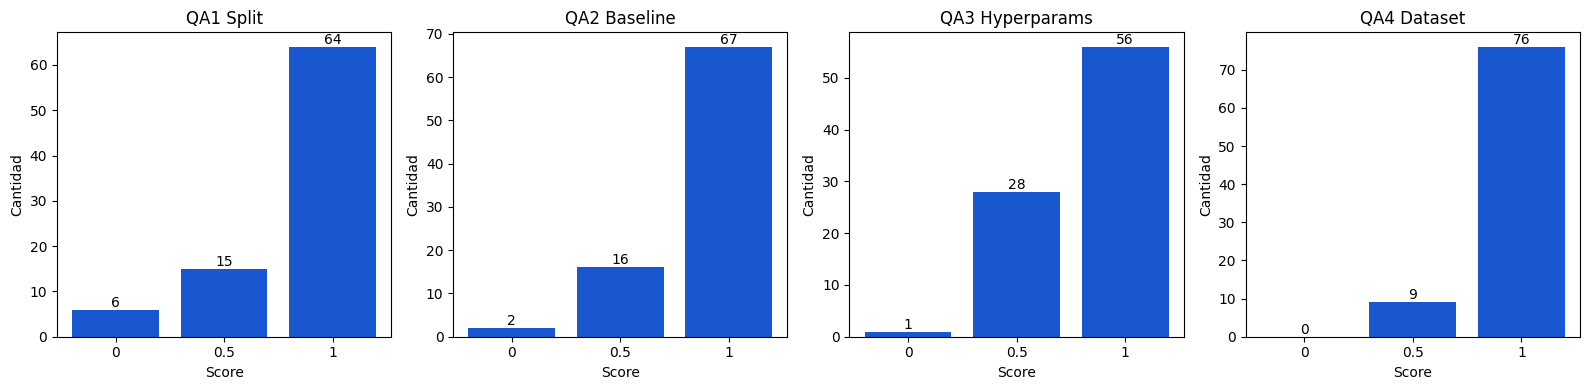

In [11]:
# - Distribución de scores por criterio QA -

dic_criterios = {
    'qa1_split':       'QA1 Split',
    'qa2_baseline':    'QA2 Baseline',
    'qa3_hyperparams': 'QA3 Hyperparams',
    'qa4_dataset':     'QA4 Dataset'
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, (str_col, str_label) in enumerate(dic_criterios.items()):
    score_counts = df_valid[str_col].astype(float).value_counts().reindex([0, 0.5, 1], fill_value=0)
    bars = axes[i].bar(['0', '0.5', '1'], score_counts.values, color='#1957d1')
    axes[i].set_title(str_label)
    axes[i].set_xlabel('Score')
    axes[i].set_ylabel('Cantidad')
    for bar in bars:
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show();

## <font color='1957d1'>Exportación de Resultados</font>

Generación del archivo CSV con los resultados completos del Quality Assessment Fase 3.

In [ ]:
# - Exportar resultados del Quality Assessment Fase 3 -

EXPORT_DIR = Path("Exports/Phase3")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

df_export = df_qa[[
    'pdf_filename',
    'qa1_split',
    'qa2_baseline',
    'qa3_hyperparams',
    'qa4_dataset',
    'qa_score_total',
    'qa_nivel',
    'area_dominio',
    'justificacion',
    'extraction_error'
]].copy()

str_output_file = EXPORT_DIR / "phase3_qa_results.csv"
df_export.to_csv(str_output_file, index=False)

print(f"Resultados exportados a: {str_output_file}")
print(f"Total de registros: {len(df_export)}")
print(f"\nDistribución de niveles:")
print(df_export['qa_nivel'].value_counts())

Resultados exportados a: Exports\Phase3\phase3_qa_results.csv
Total de registros: 85

Distribución de niveles:
qa_nivel
Alta calidad     74
Calidad media    11
Name: count, dtype: int64


: 